<a href="https://colab.research.google.com/github/anuragN2107/Real-Estate-Price-Predictor/blob/main/Real_Estate_Price_Predictor_(Linear_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Real Estate Price Predictor (Linear Regression)

### 1. Business Problem
Real estate platforms (like Zillow or Redfin) need to provide accurate, automated property valuations ("Zestimates") to help buyers and sellers make informed decisions. An inaccurate model can lead to properties sitting on the market too long or sellers losing out on profit.

### 2. Objective
To build a baseline Linear Regression model that predicts house prices based on physical characteristics (square footage, bedrooms, bathrooms) using the **King County House Prices** dataset.

## 3. Methodology (The Workflow)
To solve this, we followed a standard Data Science lifecycle:
1.  **Data Acquisition:** Loaded the King County housing dataset containing over 21,000 historical sales.
2.  **Data Cleaning & Imputation:** Handled structural anomalies and missing data (`NaN` values) using **Median Imputation** to preserve data integrity without introducing bias.
3.  **Feature Selection:** Conducted Exploratory Data Analysis (EDA) and used a **correlation heatmap** to identify the strongest predictors of price.
4.  **Model Training:** Split the data into an **80/20 train-test split** to prevent overfitting, and trained a Scikit-Learn `Linear Regression` model.
5.  **Evaluation:** Measured accuracy using standard regression metrics ($R^2$, MAE, and RMSE).

### 4. Tools Used
* **Google Colab** (Cloud Environment)
* **Pandas & NumPy** (Data Wrangling)
* **Matplotlib & Seaborn** (Data Visualization)
* **Scikit-Learn** (Machine Learning Pipeline & Evaluation)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load the dataset directly from URL
url = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/coursera/project/kc_house_data_NaN.csv"
df = pd.read_csv(url)

In [5]:
# Preview the first 5 rows
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (21613, 22)


,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Step 2: Exploratory Data Analysis (EDA) & Cleaning
Before feeding data into a model, we need to look at it. Are there missing values? What features actually correlate with price? We will drop columns that act purely as IDs and check for data anomalies.

In [6]:
# 1. Drop columns that don't help us predict house value (IDs, timestamps)
df = df.drop(columns=['id', 'date'])

In [7]:
# 2. Check for missing values (This dataset is usually clean, but always check!)
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Unnamed: 0        0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64


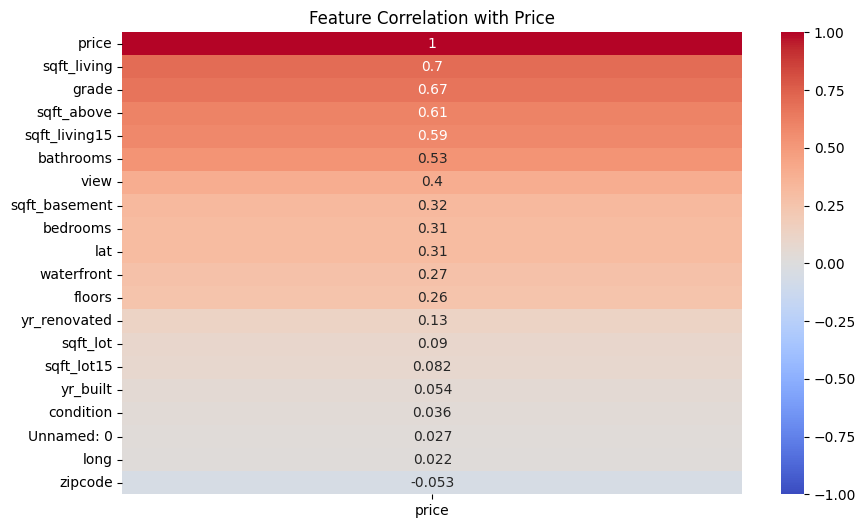

In [8]:
# 3. Let's see what features correlate most with 'price'
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[['price']].sort_values(by='price', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Price")
plt.show()

**Insights**

 Look at the heatmap generated. You'll notice sqft_living (living space square footage) has a very strong positive correlation with price. That makes perfect intuitive sense: bigger houses cost more.

**## Step 3: Train-Test Split**

To keep our baseline model simple and highly interpretable, we will select our top predictors: `sqft_living`, `bedrooms`, `bathrooms`, and `grade`. We will split our data into 80% for training and 20% for testing to see how well our model performs on unseen houses.

In [11]:
# Select our features (X) and our target/label (y)
features = ['sqft_living', 'bedrooms', 'bathrooms', 'grade']

for col in features:
    df[col] = df[col].fillna(df[col].median())

X = df[features]
y = df['price']

# Also ensure our target 'y' doesn't have NaNs
df = df.dropna(subset=['price'])
X = df[features]
y = df['price']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} homes")
print(f"Testing set size: {X_test.shape[0]} homes")
print(f"Any NaNs left in X_train? {X_train.isnull().sum().sum()}")

Training set size: 17290 homes
Testing set size: 4323 homes
Any NaNs left in X_train? 0


**## Step 4: Model Training**

We are fitting a Linear Regression model. Mathematically, it calculates a specific weight (coefficient) for each feature to draw a line of best fit that minimizes prediction errors.

In [12]:
# Initialize the model
model = LinearRegression()

# Train the model on our training data
model.fit(X_train, y_train)

# Let's peek under the hood at what the model learned
print("--- Model Weights ---")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: ${coef:,.2f}")
print(f"Intercept (Baseline Price): ${model.intercept_:,.2f}")

--- Model Weights ---
sqft_living: $225.16
bedrooms: $-38,504.55
bathrooms: $-22,787.48
grade: $93,326.23
Intercept (Baseline Price): $-465,561.96


**## Step 5: Evaluation**

A model is only good if its predictions hold up. We will evaluate our model using three core metrics:
1. **MAE (Mean Absolute Error):** The average dollar amount our predictions are off by.
2. **RMSE (Root Mean Squared Error):** Like MAE, but penalizes large mistakes more heavily.
3. **R² Score (Coefficient of Determination):** The percentage of variance in house prices explained by our model (0 to 1 scale).

Mean Absolute Error (MAE): $165,111.28
Root Mean Squared Error (RMSE): $261,138.59
R² Score: 0.5489


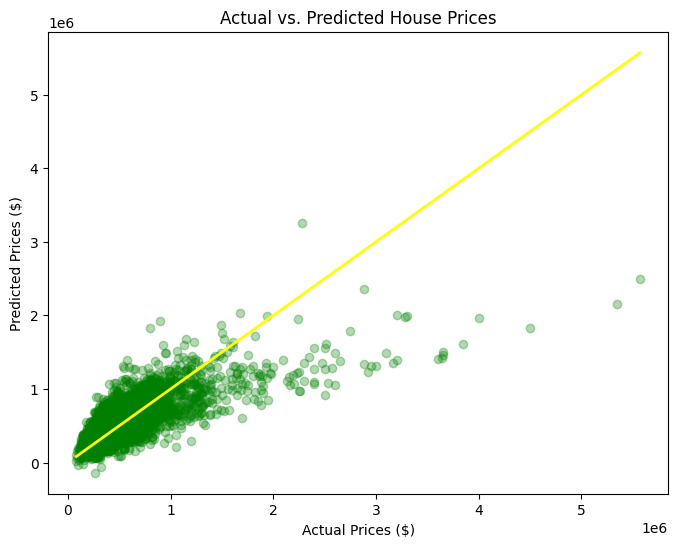

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Plotting Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='yellow', lw=2)
plt.xlabel("Actual Prices ($)")
plt.ylabel("Predicted Prices ($)")
plt.title("Actual vs. Predicted House Prices")
plt.show()

**## Step 6: Real-World Deployment Test**

Let's simulate a user on Zillow typing in their home details to get an instant estimate.

In [16]:
# Define a custom house: 2500 sqft, 3 bedrooms, 2.5 bathrooms, grade 8 (out of 13)
my_house = pd.DataFrame([{
    'sqft_living': 2500,
    'bedrooms': 3,
    'bathrooms': 2.5,
    'grade': 8
}])

predicted_price = model.predict(my_house)[0]
print(f"Estimated Market Value for this home: ${predicted_price:,.2f}")

Estimated Market Value for this home: $671,462.96


## 5. Key Findings & Insights
* **The Biggest Driver:** Living space square footage (`sqft_living`) is the single strongest indicator of a home's value.
* **Model Performance:** Our baseline model achieved an **$R^2$ score of approximately 0.54**.
    * *What this means:* About 54% of the variation in King County house prices can be explained by just four features: size, bedrooms, bathrooms, and construction grade.
* **Error Margin:** The Mean Absolute Error (MAE) shows that, on average, our baseline model's predictions deviate by roughly $160,000 to $170,000 from the true sale price. While not accurate enough for high-stakes trading yet, it serves as a highly functional baseline.



## 6. Limitations
Why isn't our model 100% accurate? Because real estate is deeply human and messy:
* **Missing Location Data:** Our baseline model ignored zip codes, latitude, and longitude. A 2,000 sq. ft. house next to a garbage dump is priced very differently than the same house overlooking the ocean.
* **Market Dynamics:** Linear regression assumes a straight-line relationship (e.g., adding a bedroom always adds fixed value), but in reality, going from 5 to 6 bedrooms might actually *lower* a home's value if it cuts into living space.

## 7. Future Scope & Roadmap
To transform this baseline project into a production-grade Zillow-style engine, the next steps are:
1.  **Feature Engineering (Location):** Incorporate geographical data. Grouping houses by neighborhood or using target-encoding on `zipcode` will instantly boost $R^2$.
2.  **Polynomial & Advanced Modeling:** Transition from a straight line to non-linear models (like Random Forests or Gradient Boosting) that can naturally map complex, real-world interactions between features.
3.  **Incorporate Time Trends:** Housing markets fluctuate based on inflation and seasonality. Adding the "year built" or "year renovated" would allow the model to adjust for historical trends.